In [1]:
import pandas as pd

from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import root_mean_squared_error

import seaborn as sns
import matplotlib.pyplot as plt

### Start mlflow experiment

In [2]:
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("new-experiment-1")

<Experiment: artifact_location='/workspaces/MLops-tests/2/mlruns/1', creation_time=1774011467365, experiment_id='1', last_update_time=1774011467365, lifecycle_stage='active', name='new-experiment-1', tags={}, workspace='default'>

## Define read DataFrame function 

In [3]:
def read_dataframe_csv(filename):
    df = pd.read_csv(filename)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td:td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    return df

def read_dataframe_parquet(filename):
    df = pd.read_parquet(filename)
    df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
    df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td:td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    return df

In [4]:
df_train = read_dataframe_parquet('../data/green_tripdata_2023-01.parquet')
df_val = read_dataframe_parquet('../data/green_tripdata_2023-02.parquet')

In [5]:
len(df_train), len(df_val)

(65946, 62574)

In [15]:
df_train.duration.mean(), df_val.duration.mean()

(np.float64(13.747575288872714), np.float64(14.00482468756992))

#### One-hot encoding

We will use the `PULocationID` and `DOLocationID` as features so we need to encode the data to make it understable by the ML algorithm

In [ ]:
categories = ['PULocationID', 'DOLocationID']

train_dicts = df_train[categories].to_dict(orient='records')


In [25]:

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

In [26]:
print(f'Feature matrix size: {X_train.shape}')

Feature matrix size: (65946, 467)


In [27]:
target = 'duration'
y_train = df_train[target].values

In [31]:
with mlflow.start_run():
    mlflow.set_tag("owner", "Fernan")
    mlflow.log_param("train-data-path", "../data/yellow_tripdata_2023-01.parquet")
    
    alpha = 0.01
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)
    
    y_pred = lr.predict(X_train)
    rmse = root_mean_squared_error(y_train, y_pred)
    print(f'Train RMSE: {rmse}')
    mlflow.log_param("rmse", rmse)

Train RMSE: 7.493745227590286


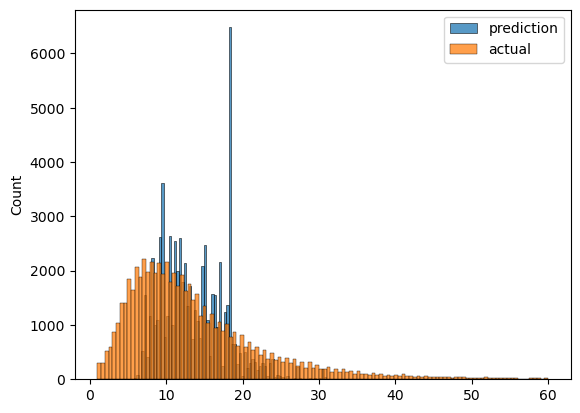

In [32]:
sns.histplot(y_pred, label='prediction')
sns.histplot(y_train, label='actual')

plt.legend();

## Validate Data

In [40]:
df_val = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-02.parquet')

In [41]:
df_val['duration'] = df_val.tpep_dropoff_datetime - df_val.tpep_pickup_datetime
df_val['duration'] = df_val.duration.dt.total_seconds() / 60

In [42]:
df_val = df_val[(df_val.duration >= 1) & (df_val.duration <= 60)].copy()
df_val[categories] = df[categories].astype('str')

In [43]:
val_dicts = df_val[categories].to_dict(orient='records')

In [44]:
X_val = dv.transform(val_dicts) 
y_val = df_val.duration.values

In [45]:
y_pred = lr.predict(X_val)

In [46]:
print(f'Train RMSE: {root_mean_squared_error(y_val, y_pred)}')

Train RMSE: 11.943512213577822


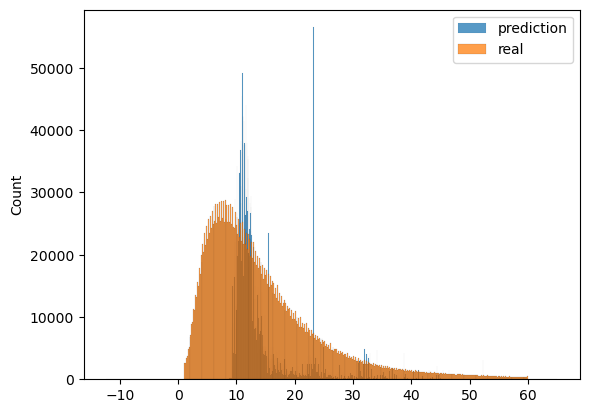

In [47]:
sns.histplot(y_pred, label="prediction")
sns.histplot(y_val, label="real")
plt.legend()